# TP : Introduction à PyTorch


PyTorch est l'une des bibliothèques de deep learning les plus utilisées aujourd'hui, tant dans la recherche que dans l'industrie. Développé par Meta AI, il se distingue par sa grande flexibilité, sa facilité d'utilisation et son mode d'exécution dynamique, qui permet de construire et d'entraîner des modèles de manière intuitive. C'est un outil incontournable pour expérimenter, prototyper et déployer des réseaux de neurones.

Dans ce TP, nous allons découvrir les concepts fondamentaux de PyTorch : la manipulation des tenseurs, l'utilisation de l'autograd pour le calcul automatique de gradients, ainsi que la construction et l'entraînement de modèles simples. L'objectif est de se familiariser avec les briques essentielles permettant de mettre en oeuvre des algorithmes d'apprentissage profond, afin de pouvoir ensuite aborder des architectures plus complexes et des projets plus avancés.

#### Import des bilbliothèques

In [1]:
import torch
import numpy as np
import random

#### Vérification du GPU et configuration du device

PyTorch peut utiliser un GPU NVIDIA pour accélérer les calculs.
torch.cuda.is_available() permet de vérifier la présence d'une carte GPU compatible.

In [ ]:
# vérifier l'existance d'une GPU
torch.cuda.is_available()

# Définir le device qu'on veut utiliser
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

Q1 : Quel device sera utilisé si aucun GPU n'est disponible ?

Réponse: <span style="color:green"> We use the CPU when no GPE is available. </span>.


#### Création de tensors

Depuis une liste Python

In [ ]:
data = [[1, 2],[3, 4]]
x_data = torch.tensor(data)

Depuis un tableau NumPy

In [ ]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

Depuis un autre tensor

In [ ]:
x_ones = torch.ones_like(x_data)
x_rand = torch.rand_like(x_data, dtype=torch.float)

Avec une forme spécifique

In [ ]:
shape = (2,3)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

In [ ]:
torch.tensor(np_array)

tensor([[1, 2],
        [3, 4]])

Q1 : Quelle différence entre torch.tensor() et torch.from_numpy() ?
    
Réponse : <span style="color:green">It is, in fact, possible to ceate a tensor using "torch.tensor(np_array)", but the refered method "torch.from_numpy(np_array)" is implemented to take advantaje of the array structure, thus being a more efficient (in terms of memory and computational time) solution. Also, by reusing the object, the original pointers are reused, thus modifying the original "np_array" object results in modifying the tensor as well. </span>.

reference: https://docs.pytorch.org/docs/main/generated/torch.from_numpy.html


In [ ]:
"""Q2 : Crée un tensor 3×3 rempli de 7."""

tensor_7s = 7*torch.ones(3,3)
tensor_7s

tensor([[7., 7., 7.],
        [7., 7., 7.],
        [7., 7., 7.]])

#### Attributs des tensors

In [ ]:
tensor = torch.rand(4,6)

print("ndim =", tensor.ndim)      # nombre de dimensions
print("shape =", tensor.shape)     # forme du tensor
print("dtype =", tensor.dtype)     # type des données
print("device =", tensor.device)    # CPU ou GPU

ndim = 2
shape = torch.Size([4, 6])
dtype = torch.float32
device = cpu


Q1 : Quelle est la dimension d'un tensor de shape (1, 3, 3) ?
    
Réponse : <span style="color:green"> It is a 3-dimensional tensor. We create a zeroes tensor with this shape and check that in th following: </span>

In [ ]:
tensor_3d = torch.zeros(1,3,3)
tensor_3d.ndim

3

#### Déplacement vers le GPU

In [ ]:
if torch.cuda.is_available():
    tensor_on_gpu = tensor.to('cuda')
    tensor_back_on_cpu = tensor_on_gpu.cpu().numpy()

In [ ]:
tensor_on_gpu.numpy()

TypeError: can't convert cuda:0 device type tensor to numpy. Use Tensor.cpu() to copy the tensor to host memory first.

Q1 : Que se passe-t-il si vous essayez tensor_on_gpu.numpy() ?

Réponse : <span style="color:green"> By running the piece of code "tensor_on_gpu.numpy()" one gets an error, as implemented above. </span>.

Q2 : Pourquoi faut-il copier le tensor sur le CPU avant d'appeler .numpy() ?
    
Réponse : <span style="color:green"> Numpy is not suited to manipulate GPU memory, thus it's necessary to share the memory to CPU before requiring the Numpy array. </span>.

#### Indexation et slicing

In [ ]:
tensor = torch.ones(4, 4)
tensor[0]       # première ligne
tensor[:, 0]    # première colonne
tensor[..., -1] # dernière colonne

tensor[:, 1] = 0

In [ ]:
""" Q1 : Modifie la dernière ligne pour qu'elle contienne [9, 9, 9, 9]. """

tensor[-1, :] = 9
tensor

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [9., 9., 9., 9.]])

#### Concaténation de tensors

In [ ]:
t1 = torch.cat([tensor, tensor, tensor], dim=1)

In [ ]:
t1.size()

torch.Size([4, 12])

Q1 : Si tensor est un tensor de size (4,4), quelle sera la taille de t1 ?
    
Réponse : <span style="color:green"> We checked that above. By joining three 4x4 tensors we obtain a 4x12 new tensor. </span>.

#### Opérations mathématiques

Multiplication matricielle

In [ ]:
y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)
y3 = torch.matmul(tensor, tensor.T)

Produit élément par élément

In [ ]:
z1 = tensor * tensor
z2 = tensor.mul(tensor)
z3 = torch.mul(tensor, tensor)

Q1 : Quelle est la condition pour que deux matrices puissent être multipliées ?
    
Réponse : <span style="color:green"> Let $A_{m \times n}$ and $B_{k \times l}$ be two matrices, then in order to the product $C = AB$ exist, one requires that row-wise vectors in $A$ to have the same dimension of column-wise vectors in $B$, this equivalent to requiring that $n = k$. </span>.

Opérations in-place

Ces opérations modifient directement le tensor d’origine.

In [ ]:
tensor.add_(5)

tensor([[ 6.,  5.,  6.,  6.],
        [ 6.,  5.,  6.,  6.],
        [ 6.,  5.,  6.,  6.],
        [14., 14., 14., 14.]])

Q2 : Pourquoi faut-il faire attention en apprentissage automatique lorsqu'on utilise des opérations in-place ?
    
Réponse : <span style="color:green"> By using in place operations, one can disrupt autograd computations. Many seemingly simple operations such as tensor slice assignments, zero_grad and operation assignments, are in-place operations.  </span>.

#### Conversion entre NumPy et PyTorch

In [ ]:
t = torch.ones(5)
n = t.numpy()
t.add_(1)

tensor([2., 2., 2., 2., 2.])

In [ ]:
n[3] = 0
t

tensor([2., 2., 2., 0., 2.])

Q3 : Que se passe-t-il si l'on modifie n après la conversion ?
    
Réponse: <span style="color:green"> As observed above, by modifying the array $n$ we internally (by object reference) modified the tensor $t$ as well. </span>.

#### Manipulation des formes (reshape, view, squeeze…)

In [ ]:
x = torch.arange(1., 8.)
x

tensor([1., 2., 3., 4., 5., 6., 7.])

Reshape

In [ ]:
x_reshaped = x.reshape(1, 7)
x_reshaped

tensor([[1., 2., 3., 4., 5., 6., 7.]])

View (partage la mémoire)

In [ ]:
z = x.view(1, 7)
z

tensor([[1., 2., 3., 4., 5., 6., 7.]])

Squeeze

In [ ]:
x_squeezed = x_reshaped.squeeze()
x_squeezed

tensor([1., 2., 3., 4., 5., 6., 7.])

Permute

In [ ]:
x_3dim = x.reshape(1,1,7)
x_permuted = x_3dim.permute(2, 0, 1)
x_permuted.shape

torch.Size([7, 1, 1])

Q1 : Quelle est la différence entre .view() et .reshape() ?
    
Réponse : <span style="color:green"> Although both are used to _reshape_ a tensor, the .view() operation makes sure to reuse the original memory storage, while .reashape() might create a new copy of the tensor in memory. Thus, if one is interested in minimize memory usage and share the memory (thus the data) between the original nad the reshaped tensor, one should use .view() </span>.

#### Indexation avancée

In [ ]:
x = torch.arange(1, 10).reshape(1, 3, 3)
x[:, 0]      # ligne 0 de la dimension 1
x[:, 1, 1]   # élément central
x[0, 0, :]   # première ligne du premier batch

tensor([1, 2, 3])

In [ ]:
"""Q1 : Extraire la diagonale [1, 5, 9]"""

x[0,:,:].diag()

tensor([1, 5, 9])

#### Graine aléatoire (random seed)

In [ ]:
torch.manual_seed(42)
random_tensor_C = torch.rand(3, 4)

Q1 : À quoi sert le random seed ?
    
Réponse : <span style="color:green"> By imposing a seed, one makes sure that (pseudo)random samples result in the same values, thus any stochastic operation can be reproduced by using the same seed. </span>.

#### Calcul de gradients et Autograd

PyTorch possède un système automatique de différentiation appelé Autograd.
Il permet de calculer facilement les gradients, indispensables pour l'apprentissage automatique.

##### Activer le suivi des gradients : requires_grad=True

In [ ]:
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3*x + 1
y

tensor(11., grad_fn=<AddBackward0>)

##### Calcul du gradient avec .backward()

In [ ]:
y.backward()
x.grad

tensor(7.)

"x.grad" contient la dérivée de y par rapport à x qui est égale à 2*x+3

Pour x=2, on devrait obtenir 7.

In [ ]:
"""Q1 : Trouver le gradient de la fonction z = 5*(x**3) pour x = 1.0"""

x = torch.tensor(1.0, requires_grad=True)
z = 5*(x**3)
z.backward()
x.grad

tensor(15.)

##### Désactiver le suivi des gradients : with torch.no_grad()

Certaines opérations ne doivent pas suivre le calcul des gradients
(ex : évaluation d’un modèle).

In [ ]:
x = torch.tensor(2.0, requires_grad=True)
y = x * 3

with torch.no_grad():
    z = y * 5

print(z.requires_grad)  # False

False


Q1 : Pourquoi ne pas calculer les gradients durant la phase de test d’un modèle ?

Réponse : <span style="color:green"> Gradient computation is used by gradient-based methods (such as Adam and SGD) during training a model. However, when solely evaluating a model, no adjustment/training is expected to happen, thus one can avoi computing the gradient graph. By doing so, computational power, time and memory are conserved. </span>.

##### Retirer un tensor du graphe de calcul : .detach()

detach() crée une copie du tensor sans suivi des gradients.

In [ ]:
x = torch.tensor(3.0, requires_grad=True)
y = x * 4

z = y.detach()
print(z.requires_grad)  # False

False


Q1 : Quelle différence entre detach() et with torch.no_grad() ?
    
Réponse : <span style="color:green"> The operation torch.no_grad() creates an environment, where no dependency graphs are computed, so it has a global effect. On the other side, .detach() ceates a new variable for which no gradient will e computed, so it is a local/pontual operaration. </span>.

##### Exemple complet : descente de gradient simple

On veut minimiser la fonction : f(w) = (w−4)²

Étape 1 : Initialisation

In [ ]:
w = torch.tensor(0.0, requires_grad=True)
learning_rate = 0.1

Étape 2 : Boucle d’optimisation

In [ ]:
for i in range(20):
    loss = (w - 4)**2

    loss.backward()        # calcul du gradient
    with torch.no_grad():
        w -= learning_rate * w.grad  # mise à jour

    w.grad.zero_()         # remettre le gradient à zéro !

    print(f"Iteration {i+1} | w = {w.item():.4f} | loss = {loss.item():.4f}")

Iteration 1 | w = 0.8000 | loss = 16.0000
Iteration 2 | w = 1.4400 | loss = 10.2400
Iteration 3 | w = 1.9520 | loss = 6.5536
Iteration 4 | w = 2.3616 | loss = 4.1943
Iteration 5 | w = 2.6893 | loss = 2.6844
Iteration 6 | w = 2.9514 | loss = 1.7180
Iteration 7 | w = 3.1611 | loss = 1.0995
Iteration 8 | w = 3.3289 | loss = 0.7037
Iteration 9 | w = 3.4631 | loss = 0.4504
Iteration 10 | w = 3.5705 | loss = 0.2882
Iteration 11 | w = 3.6564 | loss = 0.1845
Iteration 12 | w = 3.7251 | loss = 0.1181
Iteration 13 | w = 3.7801 | loss = 0.0756
Iteration 14 | w = 3.8241 | loss = 0.0484
Iteration 15 | w = 3.8593 | loss = 0.0309
Iteration 16 | w = 3.8874 | loss = 0.0198
Iteration 17 | w = 3.9099 | loss = 0.0127
Iteration 18 | w = 3.9279 | loss = 0.0081
Iteration 19 | w = 3.9424 | loss = 0.0052
Iteration 20 | w = 3.9539 | loss = 0.0033


Q1 : Que se passe-t-il si tu ne fais pas w.grad.zero_() ?
    
Réponse: <span style="color:green"> By running the operation, we reinitialize the gradient, thus in the next iteration the required radient is computed properly. Otherwise, gradients would acumulate. </span>.

##### model.eval() : à quoi ça sert ?

model.eval() place le modèle en mode évaluation.

Cela affecte uniquement certains modules qui se comportent différemment entre :

    mode entraînement : model.train()
    mode évaluation : model.eval()

model.eval() permet de modifier le comportement :

BatchNorm

    Entrainement : utilise les statistiques du batch courant
    Évaluation : utilise les moyennes/variances stockées pendant l'apprentissage

Dropout

    Entrainement : désactive aléatoirement certains neurones
    Évaluation : aucun dropout (les neurones restent actifs à 100 %)

#### Régression linéaire avec PyTorch (sans nn.Module)

Dans cette section, on va entraîner un modèle simple : y = 3*x + 2

L'objectif est que de retrouve automatiquement les paramètres w et b.

In [ ]:
# Données d'entraînement

X = torch.arange(0, 10, dtype=torch.float32).reshape(-1, 1)
y = 3 * X + 2

In [ ]:
# Initialisation des paramètres du modèle (w et b)

w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

In [ ]:
# Définition du modèle

def linear_model(x):
    return w * x + b

In [ ]:
# Fonction de perte (MSE)

def loss_fn(y_pred, y_true):
    return ((y_pred - y_true) ** 2).mean()

In [ ]:
# Boucle d’entraînement

learning_rate = 0.01
for epoch in range(200):
    y_pred = linear_model(X)
    loss = loss_fn(y_pred, y)

    loss.backward()

    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    w.grad.zero_()
    b.grad.zero_()

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss = {loss:.4f} | w={w.item():.3f}, b={b.item():.3f}")

# À la fin, w devrait être proche de 3 et b proche de 2.

Epoch 0 | Loss = 262.7352 | w=2.049, b=0.064
Epoch 20 | Loss = 0.7066 | w=3.248, b=0.447
Epoch 40 | Loss = 0.5633 | w=3.221, b=0.613
Epoch 60 | Loss = 0.4491 | w=3.198, b=0.762
Epoch 80 | Loss = 0.3581 | w=3.176, b=0.894
Epoch 100 | Loss = 0.2855 | w=3.157, b=1.013
Epoch 120 | Loss = 0.2276 | w=3.141, b=1.118
Epoch 140 | Loss = 0.1815 | w=3.126, b=1.213
Epoch 160 | Loss = 0.1447 | w=3.112, b=1.297
Epoch 180 | Loss = 0.1154 | w=3.100, b=1.372


Q1 : Que se passe-t-il si on augmente le learning_rate à 1.0 ?
    
Réponse : <span style="color:green"> By using too large stepsizes, we risk not converging to the right minima. We do that in the folllowing: </span>.

In [ ]:
# initialize
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

# Boucle d’entraînement
learning_rate = 1.0
for epoch in range(200):
    y_pred = linear_model(X)
    loss = loss_fn(y_pred, y)

    loss.backward()

    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad

    w.grad.zero_()
    b.grad.zero_()

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss = {loss:.4f} | w={w.item():.3f}, b={b.item():.3f}")

# À la fin, w devrait être proche de 3 et b proche de 2.

Epoch 0 | Loss = 546.4538 | w=248.279, b=41.179
Epoch 20 | Loss = inf | w=37432680215946226621629615364718460928.000, b=5969566965269568311893411873222033408.000
Epoch 40 | Loss = nan | w=nan, b=nan
Epoch 60 | Loss = nan | w=nan, b=nan
Epoch 80 | Loss = nan | w=nan, b=nan
Epoch 100 | Loss = nan | w=nan, b=nan
Epoch 120 | Loss = nan | w=nan, b=nan
Epoch 140 | Loss = nan | w=nan, b=nan
Epoch 160 | Loss = nan | w=nan, b=nan
Epoch 180 | Loss = nan | w=nan, b=nan


#### Régression linéaire avec torch.nn

Définition du modèle

In [2]:
import torch.nn as nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        return self.linear(x)

model = LinearRegressionModel()

Fonction de perte + Optimiseur

In [ ]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

Boucle d’entraînement

In [ ]:
for epoch in range(200):
    y_pred = model(X)
    loss = loss_fn(y_pred, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 20 == 0:
        print(f"Epoch {epoch} | Loss = {loss:.4f}")


Epoch 0 | Loss = 258.8042
Epoch 20 | Loss = 0.2140
Epoch 40 | Loss = 0.1706
Epoch 60 | Loss = 0.1360
Epoch 80 | Loss = 0.1085
Epoch 100 | Loss = 0.0865
Epoch 120 | Loss = 0.0689
Epoch 140 | Loss = 0.0550
Epoch 160 | Loss = 0.0438
Epoch 180 | Loss = 0.0349


In [ ]:
"""Q1 : Comment accéder aux paramètres appris ?"""

for p in model.parameters():
  print(p)

Parameter containing:
tensor([[3.0495]], requires_grad=True)
Parameter containing:
tensor([1.6898], requires_grad=True)


In [ ]:
"""Q2 : Ajouter une deuxième couche linéaire."""

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(in_features=1, out_features=1)
        self.linear2 = nn.Linear(in_features=1, out_features=1)

    def forward(self, x):
        x = self.linear1(x)
        x = self.linear2(x)
        return x

model = LinearRegressionModel()

#### Qu'est-ce que ça change d'ajouter une deuxième couche linéaire ?

Dans PyTorch, une couche linéaire réalise la transformation suivante :

$$\text{Linear}(x) = Wx + b$$

---

##### 1. Une seule couche linéaire

Si notre modèle contient une seule couche linéaire, alors il apprend une relation strictement linéaire :

$$\hat{y} = W_1 x + b_1$$

C'est équivalent à une régression linéaire classique. Le modèle ne peut apprendre qu'une droite.

---

##### 2. Deux couches linéaires consécutives (sans activation)

Exemple :

```python
self.linear1 = nn.Linear(1, 1)
self.linear2 = nn.Linear(1, 1)

def forward(self, x):
    x = self.linear1(x)
    x = self.linear2(x)
    return x
```
Mathématiquement :

$$\hat{y} = W_2 (W_1 x + b_1) + b_2$$
    
En développant :

$$\hat{y} =  (W_1 W_2) x + (W_2 b_1 + b_2)$$

Le modèle reste linéaire... Même si on ajoute plusieurs couches linéaires consécutives, sans activation, le résultat final est toujours une seule transformation linéaire équivalente.

##### Quand est-ce que plusieurs couches deviennent intéressantes ?

Uniquement quand on ajoute une fonction d'activation non linéaire entre les couches :

```python
self.linear1 = nn.Linear(1, 10)
self.relu = nn.ReLU()
self.linear2 = nn.Linear(10, 1)

def forward(self, x):
    return self.linear2(self.relu(self.linear1(x)))
```

Maintenant notre modèle devient :

$$\hat{y} = W_2 \sigma(W_1 x + b_1) + b_2$$

où $\sigma$ est une non-linéarité (ReLU, tanh, sigmoid…).

Le modèle n'est plus linéaire. Il peut apprendre des relations non linéaires, comme : courbes, polynômes, fonctions périodiques, données complexes…

#### Dataset & DataLoader (gestion des données)

Les DataLoader permettent de charger les données par batches, mélangées (shuffle) ou non.

Création d’un Dataset personnalisé

In [3]:
from torch.utils.data import Dataset, DataLoader

class SimpleDataset(Dataset):
    def __init__(self):
        self.X = torch.arange(0, 10, dtype=torch.float32).reshape(-1, 1)
        self.y = 3 * self.X + 2

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

Charger le Dataset dans un DataLoader

In [ ]:
dataset = SimpleDataset()
loader = DataLoader(dataset, batch_size=2, shuffle=True)

Parcourir un DataLoader

In [ ]:
for batch_X, batch_y in loader:
    print(batch_X, batch_y)

tensor([[1.],
        [8.]]) tensor([[ 5.],
        [26.]])
tensor([[3.],
        [0.]]) tensor([[11.],
        [ 2.]])
tensor([[6.],
        [2.]]) tensor([[20.],
        [ 8.]])
tensor([[4.],
        [9.]]) tensor([[14.],
        [29.]])
tensor([[5.],
        [7.]]) tensor([[17.],
        [23.]])


Q1 : Que fait l'argument shuffle=True ?
    
Réponse : <span style="color:green"> The original dataset had an order; by including the parameter shuffle=True, we randomly reshuffle the data ordering, reurning a new data permutation. </span>.

#### Application sur un vrai jeu de données d'images (MNIST via torchvision)

MNIST contient des images de chiffres 28×28 = 784 pixels.

In [4]:
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

Fonction pour convertir les images en tenseurs et les normaliser (optionnel mais classique).

In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),              # image PIL to tensor (C,H,W) entre 0 et 1
    # transforms.Normalize((0.5,), (0.5,))  # optionnel : normalisation
])

Télécharger MNIST

In [7]:
# Le dataset sera téléchargé dans le dossier "./data"

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

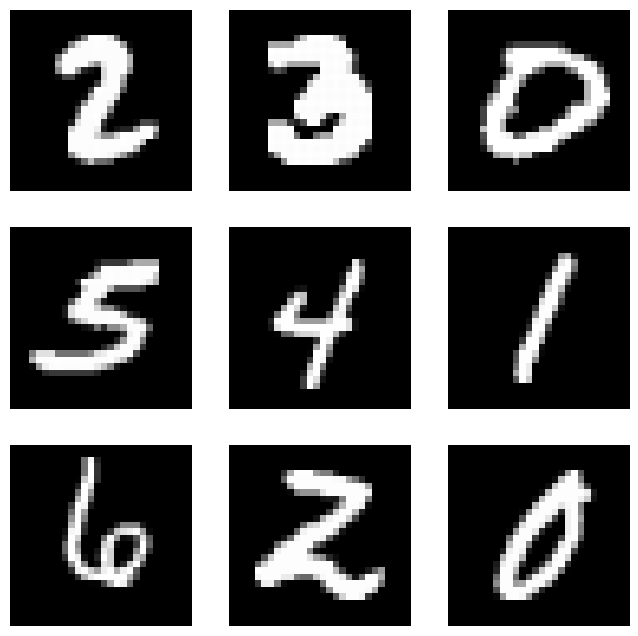

In [8]:
import matplotlib.pyplot as plt

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

Créer les Dataloader

In [12]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

### Réseaux de Neurones Profonds : MLP & CNN

Dans cette partie, nous allons créer :

    un MLP (Multi-Layer Perceptron) pour la classification de chiffres (MNIST)

    un CNN simple pour apprendre à classifier des images 1 canal (MNIST)

L'objectif est d'introduire les principales briques des architectures modernes.

#### MLP (Multi-Layer Perceptron)

Un MLP est composé uniquement de couches linéaires, séparées par des activations.

Ex :
Entrée -> Linear -> ReLU -> Linear -> ReLU -> Linear -> Sortie

In [ ]:
"""Modèle MLP TODO """

class MyMLP(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.input_size = input_size
        self.model = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, output_size),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.model(x.view(-1, self.input_size))

mlp = MyMLP(784, 10)

Fonction de perte + Optimiseur

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=0.001)

Exemple de la boucle d'entraînement (un seul epoch)

In [ ]:
for X_batch, y_batch in train_loader:
    optimizer.zero_grad()
    y_pred = mlp(X_batch)
    loss = criterion(y_pred, y_batch)
    loss.backward()
    optimizer.step()

*Q1* : Quelle activation remplace ReLU dans un MLP profond ?
    
Réponse : <span style="color:green"> Some common alternatives to ReLU are the functions LeakyReLU, ReGLU, ELU and even the Sigmoid. </span>.

Exemple de code d'entrainement du modèle pour plusieurs epochs

In [ ]:
"""Boucle d'entrainement pour 10 epochs TODO"""

plt_loss = []
for epoch in range(10):
  for X_batch, y_batch in train_loader:
    optimizer.zero_grad()
    y_pred = mlp(X_batch)
    loss = criterion(y_pred, y_batch)
    loss.backward()
    optimizer.step()
    plt_loss.append(loss.detach())
  print(f"epoch: {epoch} | loss: {loss}")

epoch: 0 | loss: 1.5580471754074097
epoch: 1 | loss: 1.4787572622299194
epoch: 2 | loss: 1.4957605600357056
epoch: 3 | loss: 1.4691067934036255
epoch: 4 | loss: 1.4692535400390625
epoch: 5 | loss: 1.4618175029754639
epoch: 6 | loss: 1.496951699256897
epoch: 7 | loss: 1.462218999862671
epoch: 8 | loss: 1.4692411422729492
epoch: 9 | loss: 1.4695972204208374


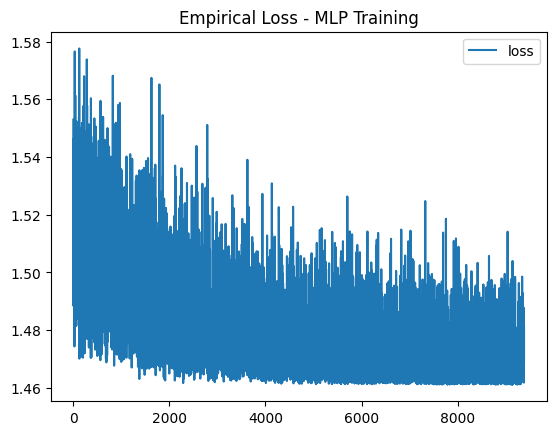

In [ ]:
plt.plot(plt_loss, label="loss")
plt.title("Empirical Loss - MLP Training")
plt.legend()
plt.show()

Evaluation sur le jeu de test




In [ ]:
mlp.eval()
test_total = 0
test_correct = 0

with torch.no_grad():
    for X_test, y_test in test_loader:
      y_pred = mlp(X_test)
      y_pred = np.argmax(y_pred, axis=1)

      # count for accuracy
      test_total += len(y_test)
      test_correct += sum(y_test==y_pred)

test_acc = test_correct/test_total

print(f"Final Test Accuracy : {test_acc:.3f}")

Final Test Accuracy : 0.979


#### Notes:

- model.train() :
    active certaines couches comme Dropout, BatchNorm en mode entraînement.

- model.eval() :
    met le modèle en mode évaluation (pas de Dropout, BatchNorm en mode inference).

- with torch.no_grad() :
    désactive la construction du graphe de gradients (moins de mémoire, plus rapide).

- torch.max(y_pred, dim=1) :
    récupère la classe prédite.

#### NN (Convolutional Neural Network)

Les CNN sont utilisés pour traiter les images.
Ils exploitent :

    des filtres convolutifs

    des features locales

    des réductions de dimension (MaxPool)

Architecture d'un CNN simple
Schéma général :

- Entrée (1×28×28)
- Conv2d
- ReLU
- MaxPool2d
- Flatten
- Linear
- Linear
- Sortie (10 classes)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 5, 3),
            nn.ReLU(),
            nn.MaxPool2d(3)
        )

        self.fc_layers = nn.Sequential(
            nn.Linear(in_features=320, out_features=100),
            nn.ReLU(),
            nn.Linear(in_features=100, out_features=10),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # flatten
        return self.fc_layers(x)

cnn = SimpleCNN()

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)

In [ ]:
for X_batch, y_batch in train_loader:
    optimizer.zero_grad()
    y_pred = cnn(X_batch)
    loss = criterion(y_pred, y_batch)
    loss.backward()
    optimizer.step()

print(f"loss after training: {loss}")

loss after training: 1.5512663125991821


Q1 : Quel est le rôle de MaxPool2d ?
    
Réponse: <span style="color:green"> A pooling layer has several utilities; first, it reduces the input dimension by applying a nonlinear function. Also, it add robustness to small variation in the input data, such as tranlations. Besides the MaxPool, other Pooling functions are possible to be used, such as the AveragePooling  </span>.
    
Q2 : Pourquoi les CNN sont-ils plus efficaces que les MLP sur les images ?

Réponse : <span style="color:green"> The main advantage of CNNs the the reuse of a unique shared convolution mask. By doing that, one reduces drastically the number of parameter to e trained/adjusted, thus also improving computational efficiency in training the model. </span>.

In [ ]:
"""Créer un CNN avec :
    3 couches convolutives
    1 couche dense finale
    des BatchNorm entre les convolutions
"""

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 5, 3),
            nn.BatchNorm2d(5),
            nn.Conv2d(5, 5, 3),
            nn.BatchNorm2d(5),
            nn.Conv2d(5, 5, 3),
        )

        self.linear = nn.Linear(2420, 10)

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # flatten
        return self.linear(x)

cnn = SimpleCNN()

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(cnn.parameters(), lr=0.001)

In [ ]:
for X_batch, y_batch in train_loader:
    optimizer.zero_grad()
    y_pred = cnn(X_batch)
    loss = criterion(y_pred, y_batch)
    loss.backward()
    optimizer.step()

print(f"loss after training: {loss}")

loss after training: 0.3346214294433594


### Exercice : Construire un Autoencodeur

Un autoencodeur est un réseau capable de :

- Encoder une donnée (image) dans un espace latent de dimension réduite.
- Décoder cette représentation latente pour reconstruire l'image d'origine.

Utilisation : débruitage, compression, détection d'anomalies, génération…


Consignes :

1. Créer une classe Autoencoder(nn.Module)

2. Implémenter :
    - un encodeur (MLP)
    - un espace latent de faible dimension (ex : 16)
    - un decodeur symétrique


3. Utiliser une loss MSE pour mesurer la qualité de reconstruction

4. Entraîner l'autoencodeur sur MNIST (train set uniquement)

5. Afficher :
    - une image originale
    - son image reconstruite


6. Tester différentes tailles de la couche latente (2, 8, 32…)


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

class Autoencoder(nn.Module):
    def __init__(self, latent_dim=16):
        super().__init__()

        self.encoder = nn.Sequential(
            # 28 x 28
            nn.Conv2d(1, 4, 5),
            nn.Dropout2d(p=0.2),
            nn.ReLU(True),
            # 24 x 24 x 4
            nn.Conv2d(4, 8, 5),
            nn.Dropout2d(p=0.2),
            nn.ReLU(True),
            # 20 x 20 x 8
            nn.Flatten(),
            nn.Linear(in_features=20*20*8, out_features=latent_dim)
        )

        ## ---- DECODEUR ----
        self.decoder = nn.Sequential(
            # latent_dim
            nn.Linear(in_features=latent_dim, out_features=20*20*8),
            nn.ReLU(True),
            nn.Unflatten(1, (8,20,20)),
            # 20 X 20 X 8
            nn.ConvTranspose2d(8, 4, kernel_size=5),
            nn.ReLU(True),
            # 24 x 24 x 4
            nn.ConvTranspose2d(4, 1, kernel_size=5),
            # nn.ReLU(True),
            # nn.Sigmoid(),
            nn.Tanh()
            # 28 x 28
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

model = Autoencoder(latent_dim=16)

In [ ]:
# Optimiseur & loss
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
# Boucle d'entraînement (train_loader déjà défini)
model.train()

n_epochs = 20
losses = []
for epoch in range(n_epochs):
    for X_batch, _ in train_loader:
        optimizer.zero_grad()
        X_pred = model(X_batch)
        loss = criterion(X_pred, X_batch)
        loss.backward()
        optimizer.step()
        losses.append(loss.detach().numpy())

    # print status
    print(f"epoch: {epoch}, loss: {loss}")

epoch: 0, loss: 0.014124195091426373
epoch: 1, loss: 0.013823562301695347
epoch: 2, loss: 0.016309456899762154
epoch: 3, loss: 0.012203498743474483
epoch: 4, loss: 0.013769947923719883
epoch: 5, loss: 0.012555578723549843
epoch: 6, loss: 0.011479021050035954
epoch: 7, loss: 0.014281715266406536
epoch: 8, loss: 0.010875959880650043
epoch: 9, loss: 0.013121454045176506
epoch: 10, loss: 0.011417219415307045
epoch: 11, loss: 0.01132490485906601
epoch: 12, loss: 0.013248558156192303
epoch: 13, loss: 0.011173006147146225
epoch: 14, loss: 0.010268745012581348
epoch: 15, loss: 0.010989483445882797
epoch: 16, loss: 0.01036866195499897
epoch: 17, loss: 0.009375321678817272
epoch: 18, loss: 0.010633163154125214
epoch: 19, loss: 0.00994086917489767


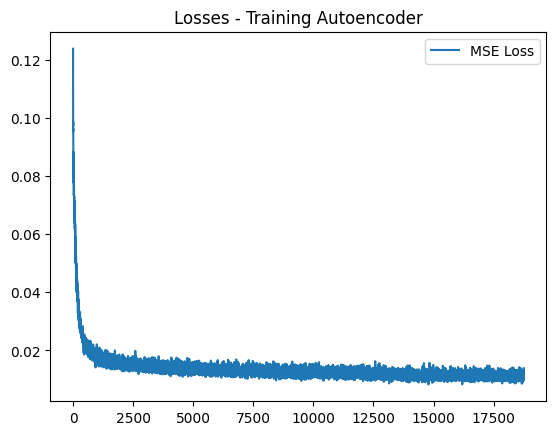

In [ ]:
plt.plot(losses, label="MSE Loss")
plt.title("Losses - Training Autoencoder")
plt.legend()
plt.show()

We compare some original figures and the autoencoded:

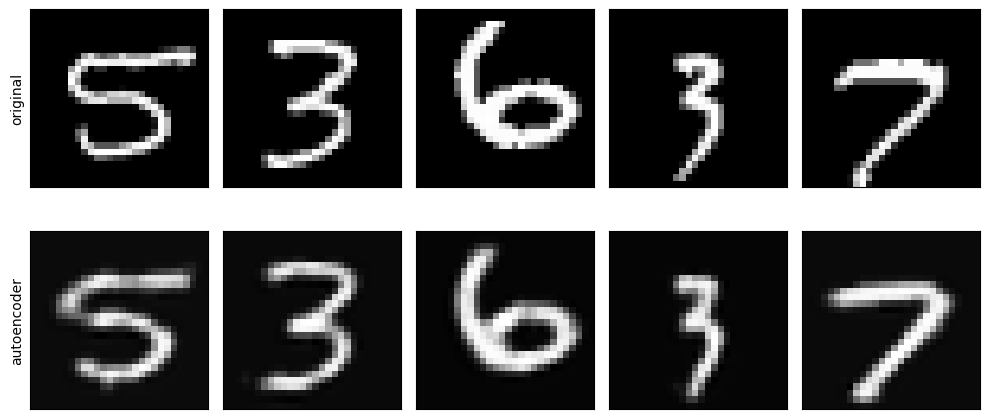

In [ ]:
model.eval()

n_cols = 5
fig, ax = plt.subplots(2, n_cols, figsize=(10, 5))

for i in range(n_cols):
    # sample image
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, _ = train_dataset[sample_idx]

    # plot figures
    ax[0][i].set_xticks([])
    ax[0][i].set_yticks([])
    ax[0][i].imshow(img.squeeze(), cmap="gray")

    #
    img_auto = model(img.unsqueeze(0)).detach().numpy()
    ax[1][i].set_xticks([])
    ax[1][i].set_yticks([])
    ax[1][i].imshow(img_auto.squeeze(), cmap="gray")

    if i == 0:
      ax[0][i].set_ylabel("original")
      ax[1][i].set_ylabel("autoencoder")

plt.tight_layout()
plt.show()

We experiment the same model with different latent dimensions. We train each model for 5 epochs to limit the required computational time and power:

In [11]:
def train_model_dim(dimension, n_epochs):
    model = Autoencoder(latent_dim=dimension)

    # Optimiseur & loss
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    # train
    model.train()
    losses = []
    for epoch in range(n_epochs):
        for X_batch, _ in train_loader:
            optimizer.zero_grad()
            X_pred = model(X_batch)
            loss = criterion(X_pred, X_batch)
            loss.backward()
            optimizer.step()
            losses.append(loss.detach().numpy())

        # print status
        print(f"dim: {dimension}, epoch: {epoch}, loss: {loss}")

    return model, losses

In [17]:
models = dict()

# iterate
n_dimensions = [2, 4, 8, 16, 32]
for dimension in n_dimensions:
    model, losses = train_model_dim(dimension, n_epochs=5)

    # save model and losses
    models[dimension] = {"model": model, "losses": losses}


dim: 2, epoch: 0, loss: 0.05629527196288109
dim: 2, epoch: 1, loss: 0.053274691104888916
dim: 2, epoch: 2, loss: 0.05079159140586853
dim: 2, epoch: 3, loss: 0.049585942178964615
dim: 2, epoch: 4, loss: 0.04211169853806496
dim: 4, epoch: 0, loss: 0.04325321689248085
dim: 4, epoch: 1, loss: 0.04574338719248772
dim: 4, epoch: 2, loss: 0.03891459107398987
dim: 4, epoch: 3, loss: 0.03971472382545471
dim: 4, epoch: 4, loss: 0.03389406576752663
dim: 8, epoch: 0, loss: 0.030442362651228905
dim: 8, epoch: 1, loss: 0.026878388598561287
dim: 8, epoch: 2, loss: 0.02512831799685955
dim: 8, epoch: 3, loss: 0.0241655595600605
dim: 8, epoch: 4, loss: 0.023428816348314285
dim: 16, epoch: 0, loss: 0.017537424340844154
dim: 16, epoch: 1, loss: 0.014053762890398502
dim: 16, epoch: 2, loss: 0.013707023113965988
dim: 16, epoch: 3, loss: 0.01199504267424345
dim: 16, epoch: 4, loss: 0.01014780718833208
dim: 32, epoch: 0, loss: 0.012066817842423916
dim: 32, epoch: 1, loss: 0.008418291807174683
dim: 32, epoch: 

In [32]:
import pickle as pkl

filename = "models.pkl"
pkl.dump(models, open(filename, "wb"))
# models = pkl.load(open(filename, "rb"))

Observe, in the following plot, tht, as expected, by augmenting the number of Kernel Dimensions, one gets better recovery losses. That is, one  recuperates with more precision the original image. This expectedly results from the fact that, by having a higher dimension, less information is lost trough compression in the bottleneck phase of the autoencoder:

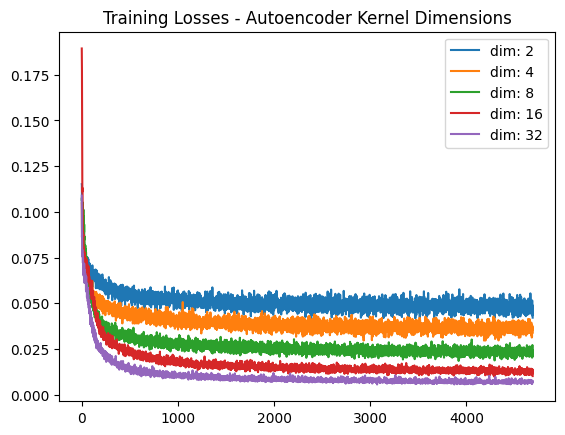

In [24]:
for dimension in n_dimensions:
  plt.plot(models[dimension]["losses"], label=f"dim: {dimension}")
  plt.legend()

plt.title("Training Losses - Autoencoder Kernel Dimensions")
plt.show()

On the other side, we observe in the following that, even when compressing the data to a 2-dimensional kernel, reasonable results are already achieved. Also, corroborating with te previous analisys, the visual quality of the recovered figures increase with the kernel dimension:

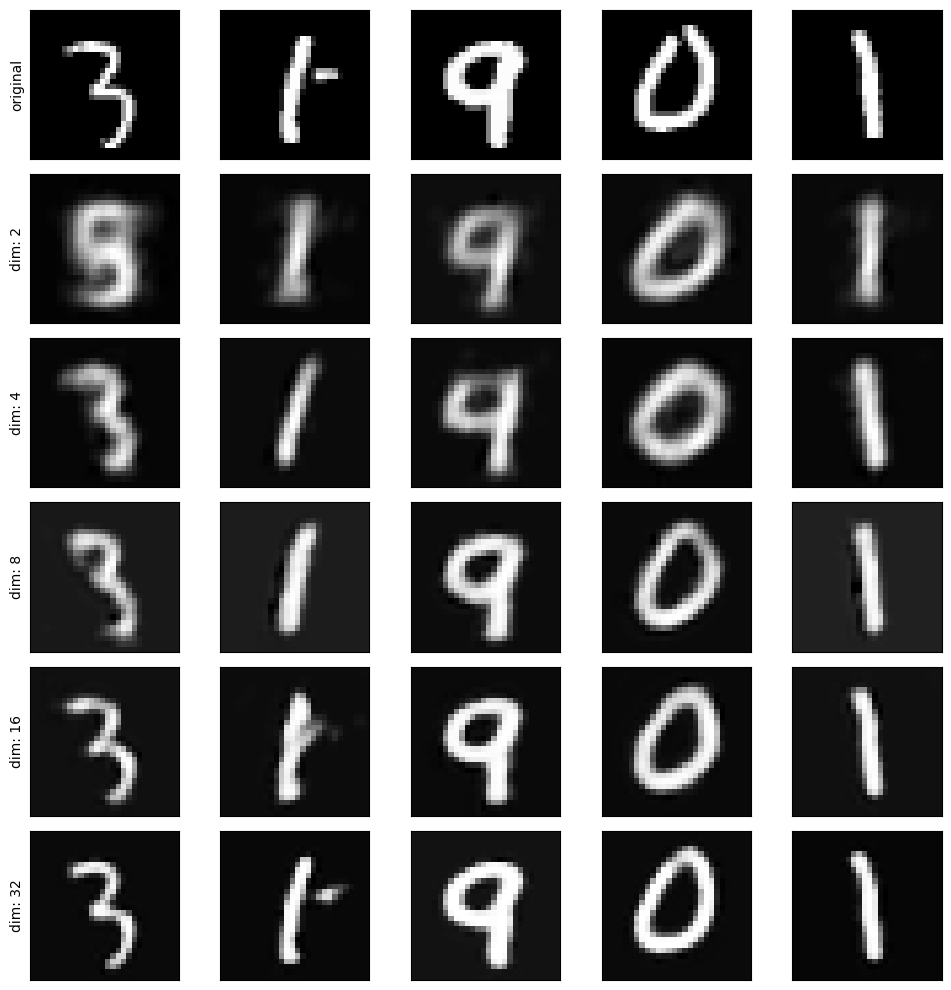

In [27]:
model.eval()

n_cols = 5
fig, ax = plt.subplots(6, n_cols, figsize=(10, 10))

for i in range(n_cols):
    # sample image
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, _ = train_dataset[sample_idx]

    # plot figures
    ax[0][i].set_xticks([])
    ax[0][i].set_yticks([])
    ax[0][i].imshow(img.squeeze(), cmap="gray")
    if i == 0:
      ax[0][i].set_ylabel("original")

    #
    for c, dimension in enumerate(n_dimensions, start=1):
      model = models[dimension]["model"]
      img_auto = model(img.unsqueeze(0)).detach().numpy()
      ax[c][i].set_xticks([])
      ax[c][i].set_yticks([])
      ax[c][i].imshow(img_auto.squeeze(), cmap="gray")
      if i == 0:
        ax[c][i].set_ylabel(f"dim: {dimension}")

plt.tight_layout()
plt.show()